# Stochastic Brock-Mirman — framework walkthrough

> Simon's Geneva Day 2 notebook (`02_Brock_Mirman_Uncertainty_DEQN.ipynb`) *builds* DEQN from scratch in TensorFlow: it hand-writes the network, the Gauss-Hermite quadrature, the loss, the training loop, and the diagnostic plots in a single file. That is the pedagogical view.
>
> **This notebook is the production view.** The same economic model is trained through the framework: one `train_from_config` call, a declarative `ModelSpec`, and a library of composable diagnostics. Nothing in this notebook is specific to Brock-Mirman except the model registration string and the plots that interpret the particular economics.

## Model

Representative agent maximizes
$$\max_{\{C_t\}} \mathbb{E}_0 \sum_t \beta^t \ln C_t \quad\text{s.t.}\quad K_{t+1} = (1-\delta)K_t + Z_t K_t^{\alpha} - C_t$$
with log utility ($\gamma = 1$), $\alpha = 0.36$, $\beta = 0.99$, $\delta = 0.1$, and AR(1) TFP in logs
$$z_{t+1} = \rho_z\, z_t + \sigma_z\, \varepsilon_{t+1}, \qquad \varepsilon \sim \mathcal{N}(0,1),$$
where $Z_t = \exp(z_t)$. Calibration mirrors Simon's notebook to make visual diffs trivial: $\rho_z = 0.9$, $\sigma_z = 0.04$.

## Euler FOC

The FOC for $s_t$ (savings rate) is
$$\frac{1}{C_t} = \beta\, \mathbb{E}_t\!\left[\frac{1 + r_{t+1} - \delta}{C_{t+1}}\right], \qquad r_{t+1} = \alpha Z_{t+1} K_{t+1}^{\alpha-1}.$$
The framework represents this as a **per-shock residual** that averages correctly under MC sampling (see [`equations.py`](../src/deqn_jax/models/brock_mirman/equations.py) for the dimensionless form and a note on why ratio forms break under stochastic expectation).

## What the framework provides

- **`ModelSpec`** — declarative model registration in `src/deqn_jax/models/brock_mirman/`.
- **`train_from_config(cfg)`** — single entry point; handles MC/quadrature expectation, rollouts, optimizer dispatch, logging.
- **`evaluate.euler_equation_errors`** — simulate ergodic path + report log₁₀|residual| distribution (Azinovic et al. 2022 gold standard).
- **`irf.run_irf`** — impulse response to any named shock.
- **`deqn_jax.plots.*`** — pure-function plots consuming `history` / `irf_results` dicts.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import TrainConfig, NetworkConfig, OptimizerConfig
from deqn_jax.training.trainer import train_from_config
from deqn_jax.models.brock_mirman import MODEL
from deqn_jax.models.brock_mirman.equations import equations as bm_equations, definitions
from deqn_jax.models.brock_mirman.dynamics import step as bm_step
from deqn_jax.models.brock_mirman.steady_state import steady_state, K_LB, K_UB, Z_LB, Z_UB
from deqn_jax.evaluate import euler_equation_errors
from deqn_jax.irf import run_irf
from deqn_jax.plots import plot_loss_curve, plot_irf_grid

## 1. Inspect the model

The `ModelSpec` is the contract. Everything the trainer needs is declared here; we don't plumb pieces by hand.

In [2]:
print(f'name          : {MODEL.name}')
print(f'states        : {MODEL.state_names}')
print(f'policies      : {MODEL.policy_names}')
print(f'equations     : {MODEL.equation_names}')
print(f'shocks        : {MODEL.shock_names} ({MODEL.n_shocks} dim)')
print()
for k, v in MODEL.constants.items():
    print(f'  {k:8s} = {v}')

ss_state, ss_policy = steady_state(MODEL.constants)
print()
print(f'Deterministic steady state:')
print(f'  K_ss     = {float(ss_state[0]):.4f}')
print(f'  z_ss     = {float(ss_state[1]):.4f}   (Z_ss = 1.0)')
print(f'  s_ss     = {float(ss_policy[0]):.4f}')
print()
print(f'Training rect: k in [{K_LB}, {K_UB}], z in [{Z_LB:.3f}, {Z_UB:.3f}]  (Z in [0.70, 1.30])')

name          : brock_mirman
states        : ('k', 'z')
policies      : ('sav_rate',)
equations     : ('euler',)
shocks        : ('eps_z',) (1 dim)

  alpha    = 0.36
  beta     = 0.99
  gamma    = 1.0
  delta    = 0.1
  rho_z    = 0.9
  sigma_z  = 0.04

Deterministic steady state:
  K_ss     = 6.3668
  z_ss     = 0.0000   (Z_ss = 1.0)
  s_ss     = 0.3270

Training rect: k in [0.9, 12.0], z in [-0.357, 0.262]  (Z in [0.70, 1.30])


## 2. Train

Config mirrors the reference recipe:

| knob | value | why |
|---|---|---|
| `episode_length` | 1 | exogenous-rect sampling phase (no rollout) |
| `initialize_each_episode` | `True` | redraw uniformly from the rect each cycle |
| `mc_samples` | 5 | matches reference Gauss-Hermite $n_\text{int}=5$ |
| `optimizer.lr_schedule` | `cosine` | our single-phase equivalent of reference's manual 3e-4 → 1e-4 drop |
| `network` | 50-50 ReLU, Xavier | matches Keras' `Dense(relu) + glorot_uniform` |

For stochastic-rollout training, simulated-moment matching, or composite losses, the same entry point applies — you'd flip `initialize_each_episode=False`, raise `episode_length`, or set `loss_type='composite'`. None of that is turned on here.

In [3]:
cfg = TrainConfig(
    model='brock_mirman',
    episodes=20001,
    batch_size=128,
    episode_length=1,
    mc_samples=5,
    n_epochs_per_rollout=1,
    n_minibatches_per_epoch=1,
    initialize_each_episode=True,
    network=NetworkConfig(hidden_sizes=(50, 50), activation='relu', init='xavier_uniform'),
    optimizer=OptimizerConfig(name='adam', learning_rate=3e-4,
                             lr_schedule='cosine', lr_min_factor=0.1),
    warm_start=False,
    seed=0,
    verbose=False,
)

policy_net, history = train_from_config(cfg)

print(f'Initial loss:  {history["loss"][0]:.3e}')
print(f'Final   loss:  {history["loss"][-1]:.3e}')

Initial loss:  1.306e+00
Final   loss:  9.655e-06


## 3. Loss curve

`plot_loss_curve` is a pure function of the returned `history` dict. Same call in any other model's notebook.

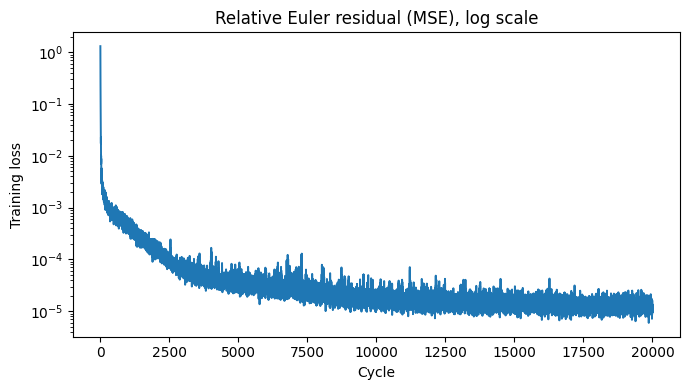

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_loss_curve(history, ax=ax, log_y=True)
ax.set_title('Relative Euler residual (MSE), log scale')
plt.tight_layout()
plt.show()

## 4. Policy surface

Savings rate $s(K, Z)$ as a heatmap over the training rect. For log utility and Cobb-Douglas production, $s$ should depend weakly on $Z$ and be essentially flat in $K$ around $\alpha\beta$ when $\delta$ is small. Strong curvature here would flag an under-trained network.

We evaluate at a grid of $(K, z)$ and convert to level TFP $Z = e^z$ for the axis.

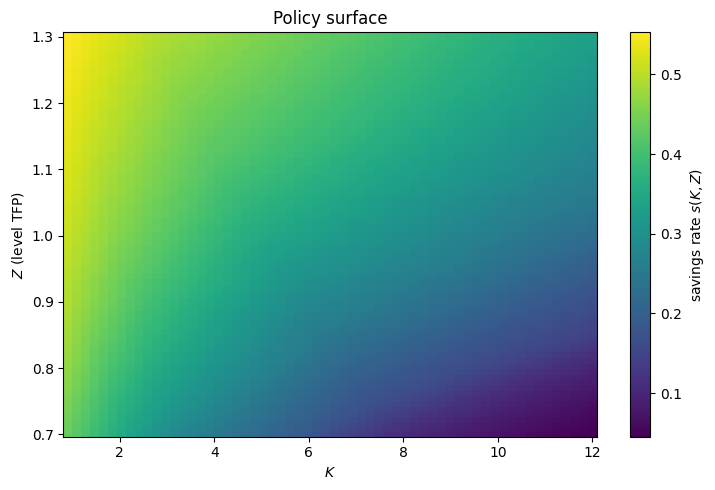

s range: [0.0454, 0.5526]


In [5]:
n_grid = 60
k_vals = jnp.linspace(K_LB, K_UB, n_grid)
z_vals = jnp.linspace(Z_LB, Z_UB, n_grid)
K_mesh, Z_mesh_log = jnp.meshgrid(k_vals, z_vals, indexing='xy')
states_grid = jnp.stack([K_mesh.ravel(), Z_mesh_log.ravel()], axis=1)  # [n_grid^2, 2]
policies_grid = jax.vmap(policy_net)(states_grid)
s_grid = np.asarray(policies_grid[:, 0]).reshape(n_grid, n_grid)

Z_level_mesh = np.exp(np.asarray(Z_mesh_log))
K_np = np.asarray(K_mesh)

fig, ax = plt.subplots(figsize=(7.5, 5))
pcm = ax.pcolormesh(K_np, Z_level_mesh, s_grid, shading='auto', cmap='viridis')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('savings rate $s(K, Z)$')
ax.set_xlabel('$K$')
ax.set_ylabel('$Z$ (level TFP)')
ax.set_title('Policy surface')
plt.tight_layout()
plt.show()

print(f's range: [{s_grid.min():.4f}, {s_grid.max():.4f}]')

## 5. Capital transition

$K_{t+1}$ vs $K_t$ at three $Z$ slices (low/mid/high). Curves are monotone increasing, shift up with $Z$, and cross the 45° line at the $Z$-conditional attractor.

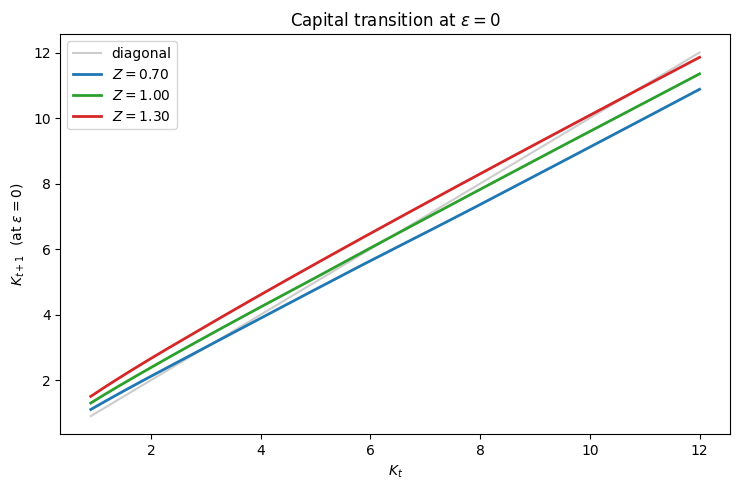

In [6]:
k_line = jnp.linspace(K_LB, K_UB, 200)
z_slices = [Z_LB, 0.0, Z_UB]
zero_shock_line = jnp.zeros((k_line.shape[0], MODEL.n_shocks))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(np.asarray(k_line), np.asarray(k_line), color='grey', alpha=0.4, label='diagonal')
colors = ['C0', 'C2', 'C3']
for z_val, color in zip(z_slices, colors):
    states = jnp.stack([k_line, jnp.full_like(k_line, z_val)], axis=1)
    policies = jax.vmap(policy_net)(states)
    next_states = bm_step(states, policies, zero_shock_line, MODEL.constants)
    k_next = np.asarray(next_states[:, 0])
    ax.plot(np.asarray(k_line), k_next, color=color, lw=2,
            label=fr'$Z = {np.exp(z_val):.2f}$')
ax.set_xlabel('$K_t$')
ax.set_ylabel('$K_{t+1}$  (at $\\varepsilon = 0$)')
ax.set_title('Capital transition at $\\varepsilon = 0$')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Pointwise Euler residual surface

At each $(K, Z)$, evaluate the raw Euler residual
$$\mathrm{resid}(K, z) = u'(C) - \beta\, \mathbb{E}_\varepsilon\!\left[u'(C')\,(1 + r' - \delta)\right],$$
estimating the expectation with 200 antithetic-paired MC draws. A well-trained policy gives a residual near zero across the full rect; larger |residual| at the edges is normal (sparser sampling there) but should not exceed the ergodic residual magnitude.

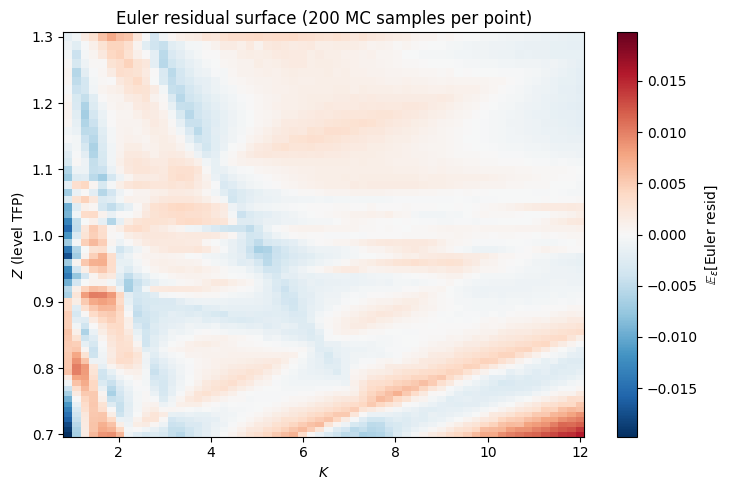

mean |resid| = 1.795e-03
max  |resid| = 1.974e-02


In [7]:
from deqn_jax.training.loss import sample_antithetic_shocks

n_mc = 200
eps_shocks = sample_antithetic_shocks(jax.random.PRNGKey(7),
                                       n_mc // 2, states_grid.shape[0],
                                       MODEL.n_shocks, 1.0)

policies_flat = jax.vmap(policy_net)(states_grid)

def per_shock_resid(shock):
    next_states = bm_step(states_grid, policies_flat, shock, MODEL.constants)
    next_policies = jax.vmap(policy_net)(next_states)
    res = bm_equations(states_grid, policies_flat, next_states, next_policies,
                       MODEL.constants)
    return res['euler']

all_resid = jax.vmap(per_shock_resid)(eps_shocks)     # [n_mc, n_points]
mean_resid = np.asarray(all_resid.mean(axis=0)).reshape(n_grid, n_grid)

fig, ax = plt.subplots(figsize=(7.5, 5))
vmax = float(np.abs(mean_resid).max())
pcm = ax.pcolormesh(K_np, Z_level_mesh, mean_resid, shading='auto',
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$\mathbb{E}_\varepsilon[\mathrm{Euler\ resid}]$')
ax.set_xlabel('$K$')
ax.set_ylabel('$Z$ (level TFP)')
ax.set_title(f'Euler residual surface ({n_mc} MC samples per point)')
plt.tight_layout()
plt.show()

print(f'mean |resid| = {np.mean(np.abs(mean_resid)):.3e}')
print(f'max  |resid| = {np.max(np.abs(mean_resid)):.3e}')

## 7. Ergodic simulation

Simulate 10,000 periods from the deterministic steady state. The framework's `euler_equation_errors` helper returns both the residuals (per equation, per period) and the simulated state path.

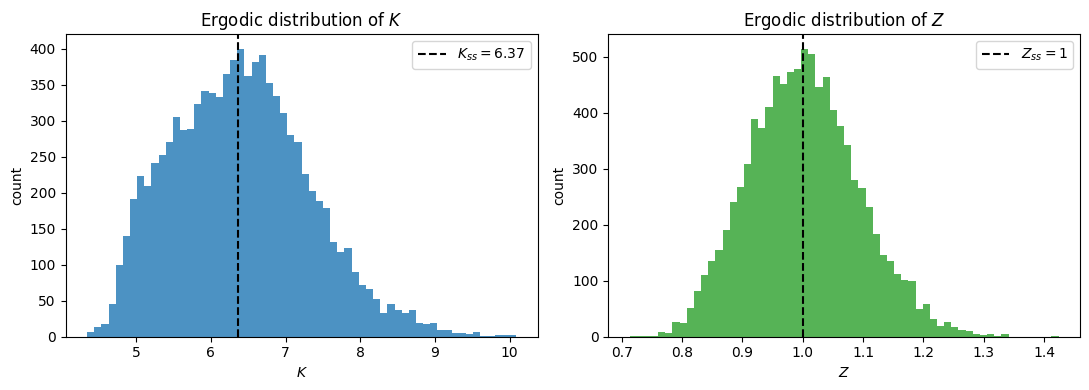

K  mean / std = 6.401 / 0.919
Z  mean / std = 1.002 / 0.091


In [8]:
eval_result = euler_equation_errors(policy_net, MODEL, n_periods=10_000, seed=123)
states_path = np.asarray(eval_result['states'])
resid_path = np.asarray(eval_result['residuals'])

K_path = states_path[:, 0]
Z_path = np.exp(states_path[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(K_path, bins=60, color='C0', alpha=0.8)
axes[0].axvline(float(ss_state[0]), color='k', ls='--', label=f'$K_{{ss}} = {float(ss_state[0]):.2f}$')
axes[0].set_xlabel('$K$'); axes[0].set_ylabel('count'); axes[0].set_title('Ergodic distribution of $K$')
axes[0].legend()

axes[1].hist(Z_path, bins=60, color='C2', alpha=0.8)
axes[1].axvline(1.0, color='k', ls='--', label='$Z_{ss} = 1$')
axes[1].set_xlabel('$Z$'); axes[1].set_ylabel('count'); axes[1].set_title('Ergodic distribution of $Z$')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'K  mean / std = {K_path.mean():.3f} / {K_path.std():.3f}')
print(f'Z  mean / std = {Z_path.mean():.3f} / {Z_path.std():.3f}')

## 8. Euler accuracy diagnostics

The Azinovic et al. (2022) DEQN accuracy report: percentile table of $\log_{10}|\mathrm{resid}|$ along the simulated ergodic path, both in raw units (what the loss sees) and in the dimensionless $|\mathrm{resid}/u'(C)|$ units used across the literature for cross-study comparison.

The dimensionless metric answers "how far off is the Euler FOC, expressed as a fraction of marginal utility" — the interpretation is that a value of $-3$ means the Euler condition holds to 0.1% accuracy, $-4$ to 0.01%, etc. Grade thresholds (Good / Acceptable / Poor) follow the Den Haan–Marcet convention.

In [9]:
from deqn_jax.evaluate import print_euler_errors
from deqn_jax.models.brock_mirman.equations import definitions as bm_defs
import jax

# Dimensionless residual = raw / u'(C) at the sampled state.
# Reconstruct u'(C) by re-running definitions on the saved states + current policy.
states_jnp = jnp.asarray(states_path)
policies_jnp = jax.vmap(policy_net)(states_jnp)
defs_path = bm_defs(states_jnp, policies_jnp, MODEL.constants)
u_c_path = np.asarray(defs_path['u_c'])            # [T]
dimless_resid = resid_path[:, 0] / u_c_path         # [T]

# 1) Raw-unit table via the framework helper.
print_euler_errors(eval_result, label='raw residual units')

# 2) Dimensionless table, same format.
def _pct_row(name, vals):
    lg = np.log10(np.maximum(np.abs(vals), 1e-20))
    p = np.percentile(lg, [50, 95, 99, 99.9])
    grade = ('Very good' if lg.mean() < -4 else
             'Good'      if lg.mean() < -3 else
             'Acceptable'if lg.mean() < -2 else 'POOR')
    print(f'{name:>30s}  {lg.mean():>7.2f}  {p[0]:>7.2f}  {p[1]:>7.2f}  '
          f'{p[2]:>7.2f}  {p[3]:>7.2f}  {lg.max():>7.2f}  {grade:>12s}')

print('\nEuler Equation Errors (log10) — dimensionless |resid/u_c|')
print('=' * 100)
print(f'{"Equation":>30s}  {"Mean":>7s}  {"p50":>7s}  {"p95":>7s}  {"p99":>7s}  {"p99.9":>7s}  {"Max":>7s}  {"Grade":>12s}')
print('-' * 100)
_pct_row('euler', dimless_resid)
print()


Euler Equation Errors (log10) — raw residual units
                      Equation     Mean      p50      p95      p99    p99.9      Max         Grade
----------------------------------------------------------------------------------------------------
                         euler    -2.38    -2.29    -1.75    -1.56    -1.39    -1.28    Acceptable
----------------------------------------------------------------------------------------------------
                       OVERALL    -2.38    -2.29    -1.75    -1.56    -1.39    -1.28

  Mean log10 error: -2.38 → 4.1e-03 (<1% Acceptable)
  Max  log10 error: -1.28 → 5.2e-02 (<10% Acceptable)

Euler Equation Errors (log10) — dimensionless |resid/u_c|
                      Equation     Mean      p50      p95      p99    p99.9      Max         Grade
----------------------------------------------------------------------------------------------------
                         euler    -2.27    -2.17    -1.66    -1.49    -1.34    -1.22    Acceptab

### Errors conditional on state

Ergodic errors can hide bad pockets — residuals can be uniformly small except in an edge region. Report the dimensionless residual by $K$-quartile of the simulated path so any sub-region weakness shows up.

In [10]:
k_quartiles = np.quantile(K_path, [0.25, 0.50, 0.75])
bin_labels = [f'K ≤ {k_quartiles[0]:.2f}',
              f'{k_quartiles[0]:.2f} < K ≤ {k_quartiles[1]:.2f}',
              f'{k_quartiles[1]:.2f} < K ≤ {k_quartiles[2]:.2f}',
              f'K > {k_quartiles[2]:.2f}']
bin_idx = np.digitize(K_path, k_quartiles)        # 0..3

print(f'{"K bin":>36s}  {"n":>6s}  {"mean":>7s}  {"p50":>7s}  {"p95":>7s}  {"p99":>7s}')
print('-' * 82)
for b, label in enumerate(bin_labels):
    vals = dimless_resid[bin_idx == b]
    lg = np.log10(np.maximum(np.abs(vals), 1e-20))
    p = np.percentile(lg, [50, 95, 99])
    print(f'{label:>36s}  {len(vals):>6d}  {lg.mean():>7.2f}  {p[0]:>7.2f}  {p[1]:>7.2f}  {p[2]:>7.2f}')


                               K bin       n     mean      p50      p95      p99
----------------------------------------------------------------------------------
                            K ≤ 5.70    2375    -2.18    -2.09    -1.55    -1.42
                     5.70 < K ≤ 6.37    2375    -2.30    -2.20    -1.72    -1.56
                     6.37 < K ≤ 7.00    2375    -2.31    -2.21    -1.74    -1.62
                            K > 7.00    2375    -2.26    -2.17    -1.69    -1.55


### Distribution of errors

Histogram of the dimensionless $\log_{10}|\mathrm{resid}/u'(C)|$. The table above is the numeric summary; this shows distribution shape (long-tail vs tight-peak).

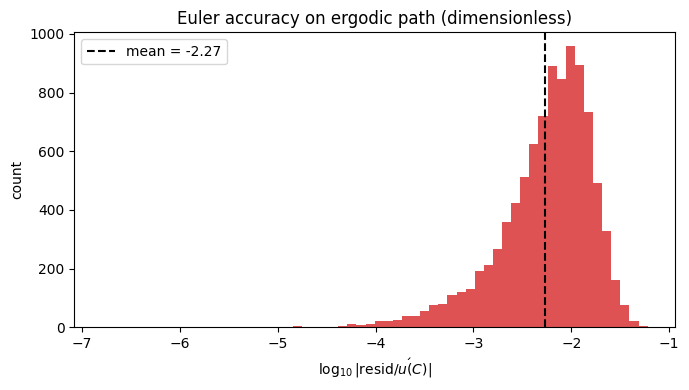

In [11]:
log_abs_resid = np.log10(np.maximum(np.abs(dimless_resid), 1e-20))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_abs_resid, bins=60, color='C3', alpha=0.8)
ax.axvline(log_abs_resid.mean(), color='k', ls='--',
           label=f'mean = {log_abs_resid.mean():.2f}')
ax.set_xlabel(r'$\log_{10}|\mathrm{resid}/u\'(C)|$')
ax.set_ylabel('count')
ax.set_title('Euler accuracy on ergodic path (dimensionless)')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Impulse response to a TFP shock

One-off +1σ innovation to $\varepsilon_z$ at period 1, then deterministic continuation. The framework's `run_irf` handles shock injection and records every state, policy, definition, and equation residual along the path. `plot_irf_grid` is a generic multi-panel plotter over the returned dict.

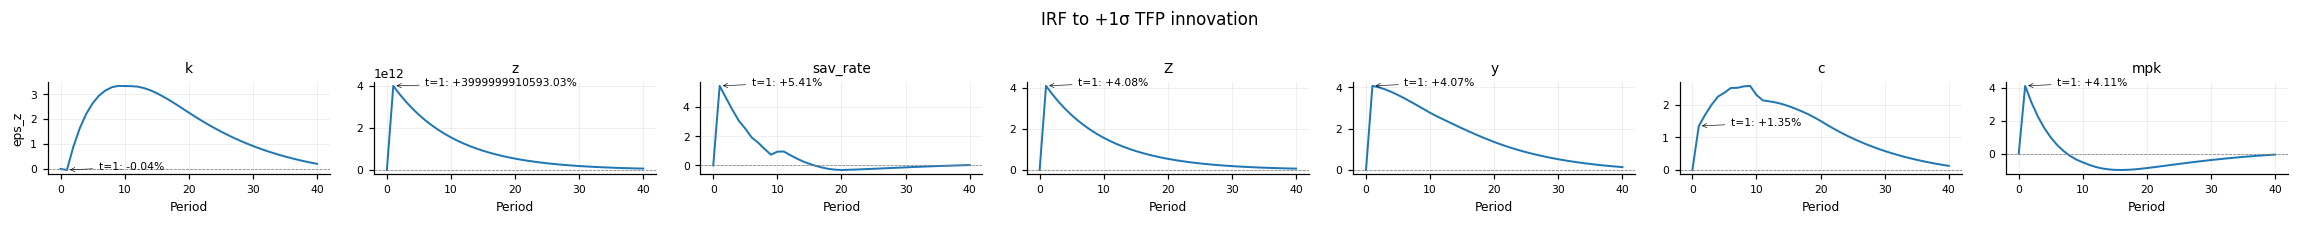

In [12]:
irf_results = run_irf(policy_net, MODEL, shock_name='eps_z',
                      shock_size=1.0, horizon=40)

variables_to_plot = ['k', 'z', 'sav_rate', 'Z', 'y', 'c', 'mpk']
fig = plot_irf_grid({'eps_z': irf_results}, variables=variables_to_plot,
                    title='IRF to +1σ TFP innovation')
plt.show()

## Summary

- Same economic model as the reference notebook; zero lines of training-loop, loss, or optimizer code in the notebook itself.
- Diagnostics are composable: `history` → loss plots; trained `policy_net` + `MODEL` → policy/residual surfaces, ergodic stats, IRFs.
- The two primitives that make this work are the `ModelSpec` data contract and the `train_from_config` entry point. Every ported model will follow this same notebook template, swapping only the model registration string and the plots that are specific to its economics.

Template for per-model notebooks:
1. Preamble with economics and FOCs
2. `ModelSpec` inspection
3. `train_from_config(cfg)`
4. Loss curve (`plot_loss_curve`)
5. Policy / definition surfaces (model-specific)
6. Pointwise residual surface (MC over shocks)
7. Ergodic simulation + state histograms
8. `log₁₀|resid|` distribution on ergodic path
9. IRF via `run_irf` + `plot_irf_grid`